In [1]:
pip install yfinance scikit-learn pandas numpy matplotlib statsmodels

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.5 MB 12.4 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 12.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 11.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 11.0 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15670 sha256=026be22572d328386ff3fa46886273cedf230b29e80cdee3bd9ac0e05b3c87c8
  Stored in directory: c:\users\mbelk\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking
Note: you may need to restart the kernel to use upd


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Download 5 years of AAPL adjusted closing prices
ticker = "AAPL"
data = yf.download(ticker, start="2019-01-01", end="2024-01-01", auto_adjust=True)

# Keep only Close price
data = data[['Close']].copy()
data.dropna(inplace=True)

print(f"Data shape: {data.shape}")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Data shape: (1258, 1)
Price           Close
Ticker           AAPL
Date                 
2019-01-02  37.503735
2019-01-03  33.768078
2019-01-04  35.209614
2019-01-07  35.131245
2019-01-08  35.800953


In [4]:
# daily returns
data['Daily_Return'] = data['Close'].pct_change()
data.dropna(inplace=True)

print(data.head())
print(f"\nMissing values: {data.isnull().sum().sum()}")

Price           Close Daily_Return
Ticker           AAPL             
Date                              
2019-01-03  33.768078    -0.099608
2019-01-04  35.209614     0.042689
2019-01-07  35.131245    -0.002226
2019-01-08  35.800953     0.019063
2019-01-09  36.408916     0.016982

Missing values: 0


In [5]:
# lag features (previous 5 days of returns) to predict next day return
lags = 5
for i in range(1, lags + 1):
    data[f'Lag_{i}'] = data['Daily_Return'].shift(i)

data.dropna(inplace=True)

# define features and target
X = data[[f'Lag_{i}' for i in range(1, lags + 1)]]
y = data['Daily_Return']

# train/test (80/20), no shuffle preserve time order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 1001
Testing samples:  251


In [6]:
# train model
model = LinearRegression()
model.fit(X_train, y_train)

# predict on test set
y_pred = model.predict(X_test)

# evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

RMSE: 0.013010
MAE:  0.009898


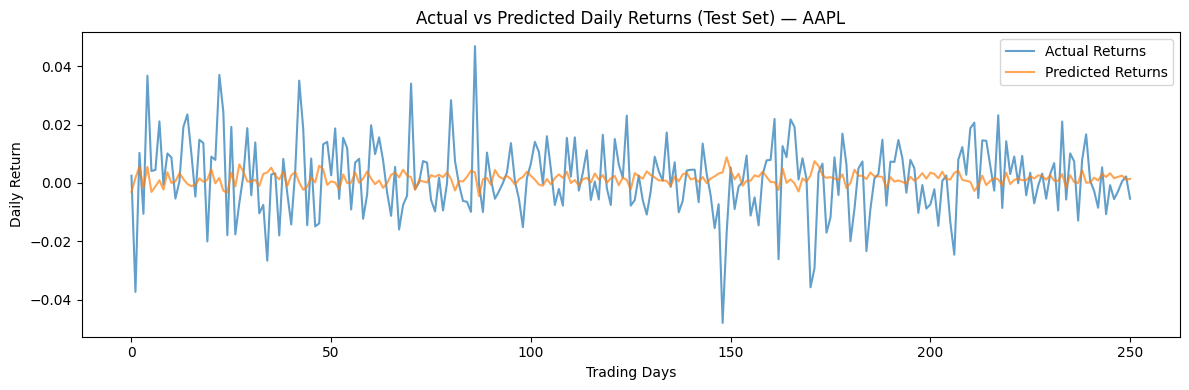

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values, label='Actual Returns', alpha=0.7)
plt.plot(y_pred,        label='Predicted Returns', alpha=0.7)
plt.title('Actual vs Predicted Daily Returns (Test Set) — AAPL')
plt.xlabel('Trading Days')
plt.ylabel('Daily Return')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

In [10]:
test_returns = y_test.copy()

# --- annual return ---
# compound daily returns over the test period
cumulative_return = (1 + test_returns).prod()
n_days = len(test_returns)
annual_return = cumulative_return ** (252 / n_days) - 1

# --- sharpe ratio ---
risk_free_daily = 0.05 / 252
excess_returns   = test_returns - risk_free_daily
sharpe_ratio     = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

# --- sortino ratio ---
# penalise downside (negative) returns
downside_returns = excess_returns[excess_returns < 0]
downside_std     = downside_returns.std()
sortino_ratio    = (excess_returns.mean() / downside_std) * np.sqrt(252)

print(f"  Financial Metrics: AAPL Test Set")
print(f"  Annual Return : {annual_return * 100:.2f}%")
print(f"  Sharpe Ratio  : {sharpe_ratio:.4f}")
print(f"  Sortino Ratio : {sortino_ratio:.4f}")

  Financial Metrics: AAPL Test Set
  Annual Return : 49.61%
  Sharpe Ratio  : 1.8443
  Sortino Ratio : 2.8761


In [11]:
summary = pd.DataFrame({
    'Metric':  ['Annual Return', 'Sharpe Ratio', 'Sortino Ratio', 'RMSE', 'MAE'],
    'Value':   [f"{annual_return*100:.2f}%",
                f"{sharpe_ratio:.4f}",
                f"{sortino_ratio:.4f}",
                f"{rmse:.6f}",
                f"{mae:.6f}"]
})
print(summary.to_string(index=False))

       Metric    Value
Annual Return   49.61%
 Sharpe Ratio   1.8443
Sortino Ratio   2.8761
         RMSE 0.013010
          MAE 0.009898
